### The ```factive``` variable represents the fraction of active tracking wire hits used in a track reconstruction relative to the total expected hits.

## Data Generation
### The perturbed tracking datasets analyzed below are explicitly generated by running the standalone script:* `01_Data_Perturbation.ipynb` This notebook loads the static binary files directly from disk to evaluate model stability.


In [ ]:
import uproot
import joblib
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd

 

# 1. Define the file parameters
DATA_DIR = "./" 
training_dataset_filename = DATA_DIR + "trkqual_tree_v2.0_training.root"
training_dataset_treename = "trkqualtree"

In [2]:
def add_useful_columns(batch):
    # Calculate magnitude of the momenta
    batch['trk_ent.mom'] = (batch['trk_ent.mom.fCoordinates.fX']**2 + batch['trk_ent.mom.fCoordinates.fY']**2 + batch['trk_ent.mom.fCoordinates.fZ']**2)**0.5
    batch['trk_ent_mc.mom'] = (batch['trk_ent_mc.mom.fCoordinates.fX']**2 + batch['trk_ent_mc.mom.fCoordinates.fY']**2 + batch['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
    
    # For masks
    #batch['ent_fit_is_highmom'] = ak.flatten(ak.any( (batch['demfit.mom']>80) & (batch['demfit.sid']==0), axis=-1, keepdims=True))
    
    # For training features
    batch['trk.factive'] = batch['trk.nactive'] / batch['trk.nhits']
    batch['trk.fambig'] = batch['trk.nnullambig'] / batch['trk.nactive']
    batch['trk.fstraws'] = batch['trk.nmatactive'] / batch['trk.nactive']

In [3]:
def load_training_arrays_batched(filepath, treename, step_size="50 MB", start_code=173):
    tree = uproot.open(f"{filepath}:{treename}")
    print(f"{filepath.split('/')[-1]}: {tree.num_entries} entries")

    out = {k: [] for k in [
        "trk_ent_mom", "trk_ent_mc_mom", "nactive", "factive",
        "fambig", "fstraws", "t0err", "fitcon", "momerr"
    ]}

    needed = [
        # mask inputs
        "trk.status", "trk.goodfit", "trk_ent_pars.t0err", "trk_sim.startCode",

        # direct outputs / raw
        "trk.nactive", "trk.fitcon", "trk_ent.momerr",

        # required by add_useful_columns for derived feature columns
        "trk.nhits", "trk.nnullambig", "trk.nmatactive",

        # required by add_useful_columns for momentum magnitudes
        "trk_ent.mom.fCoordinates.fX",
        "trk_ent.mom.fCoordinates.fY",
        "trk_ent.mom.fCoordinates.fZ",
        "trk_ent_mc.mom.fCoordinates.fX",
        "trk_ent_mc.mom.fCoordinates.fY",
        "trk_ent_mc.mom.fCoordinates.fZ",
    ]

    for batch in tree.iterate(filter_name=needed, step_size=step_size, library="ak"):
        add_useful_columns(batch)

        t0 = batch["trk_ent_pars.t0err"]
        t0_np = ak.to_numpy(t0)  # 1D numeric after your selection style
        valid_t0 = np.isfinite(t0_np)   # handles NaN and inf
        mask = (
            (batch["trk.status"] > 0)
            & (batch["trk.goodfit"] == 1)
            & ~ak.is_none(t0)
            & valid_t0
            & (batch["trk_sim.startCode"] == start_code)
        )

        out["trk_ent_mom"].append(ak.to_numpy(batch["trk_ent.mom"][mask]))
        out["trk_ent_mc_mom"].append(ak.to_numpy(batch["trk_ent_mc.mom"][mask]))
        out["nactive"].append(ak.to_numpy(batch["trk.nactive"][mask]))
        out["factive"].append(ak.to_numpy(batch["trk.factive"][mask]))
        out["fambig"].append(ak.to_numpy(batch["trk.fambig"][mask]))
        out["fstraws"].append(ak.to_numpy(batch["trk.fstraws"][mask]))
        out["t0err"].append(ak.to_numpy(t0[mask]))
        out["fitcon"].append(ak.to_numpy(batch["trk.fitcon"][mask]))
        out["momerr"].append(ak.to_numpy(batch["trk_ent.momerr"][mask]))

    for k, chunks in out.items():
        out[k] = np.concatenate(chunks) if chunks else np.array([], dtype=np.float64)
    return out

# 4. Execute the loader tool to create data_dict globally in this notebook
data_dict = load_training_arrays_batched(training_dataset_filename, training_dataset_treename)

trkqual_tree_v2.0_training.root: 452686 entries


In [ ]:
best_model = joblib.load("./xgb_trkqual_best_model_v1.joblib")
booster = best_model.get_booster()

input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
booster.feature_names = input_var_names

print("Baseline model loaded successfully.")

Baseline model loaded successfully.


In [5]:
# 1. SETUP: Reassemble the full feature matrix from the data_dict in the original file
#input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
x_full = np.column_stack([data_dict[k] for k in input_var_names])

# 2. REGENERATE MASKS: Use the raw momentum arrays to find quality tracks 
# Since the data_dict contains the raw track info, we compute the masks here
mom_res = data_dict["trk_ent_mom"] - data_dict["trk_ent_mc_mom"]
high_qual = (mom_res > -0.25) & (mom_res < 0.25)
low_qual = mom_res > 0.7

# Assemble the full binary truth target array
y_full = np.zeros(len(x_full))
y_full[high_qual] = 1
y_full[low_qual] = 0

# 3. CHOOSE CUT POINT: We use the exact threshold value from the trained model which is 0.92

trkqual_cut = 0.92

# Generate fresh continuous baseline probabilities using the loaded best_model file
y_pred_prob = best_model.predict_proba(x_full)[:, 1]
bdt_pass = y_pred_prob >= trkqual_cut

# 4. STATISTICAL FUNCTIONS: Calculate fraction means and tracking uncertainties
x_full_df = pd.DataFrame(x_full, columns=input_var_names)
f_track_full = x_full_df['factive'].values

def f_and_sigma(f_vals):
    N = len(f_vals)
    if N == 0: return 0, 0, 0 # Protection against division-by-zero errors
    f = f_vals.mean()
    sigma = np.sqrt(f * (1 - f) / N)
    return f, sigma, N

# Split populations strictly by their quality tracks AND their BDT cut pass state
sig_pass = bdt_pass & (y_full == 1) #High Quality Tracks
bkg_pass = bdt_pass & (y_full == 0) #Low quality Tracks

f_sig_before, s_sig_before, N_sig_before = f_and_sigma(f_track_full[y_full == 1])
f_bkg_before, s_bkg_before, N_bkg_before = f_and_sigma(f_track_full[y_full == 0])
f_sig_after,  s_sig_after,  N_sig_after  = f_and_sigma(f_track_full[sig_pass])
f_bkg_after,  s_bkg_after,  N_bkg_after  = f_and_sigma(f_track_full[bkg_pass])

# 5. PRINT REPORT: Output a table
print(f"BDT selection threshold cut: {trkqual_cut:.2f}")
print()
print(f"{'Tracking Category':30s} {'N tracks':>8s} {'f_active':>10s} {'±σ':>8s}")
print("-" * 62)
print(f"{'Signal (before cut)':30s} {N_sig_before:8d} {f_sig_before:10.4f} {s_sig_before:8.4f}")
print(f"{'Signal (after cut)':30s} {N_sig_after:8d} {f_sig_after:10.4f} {s_sig_after:8.4f}")
print(f"{'Background (before cut)':30s} {N_bkg_before:8d} {f_bkg_before:10.4f} {s_bkg_before:8.4f}")
print(f"{'Background (after cut)':30s} {N_bkg_after:8d} {f_bkg_after:10.4f} {s_bkg_after:8.4f}")

BDT selection threshold cut: 0.92

Tracking Category              N tracks   f_active       ±σ
--------------------------------------------------------------
Signal (before cut)              303990     0.9463   0.0004
Signal (after cut)               172011     0.9592   0.0005
Background (before cut)          148696     0.9104   0.0007
Background (after cut)            31694     0.9458   0.0013


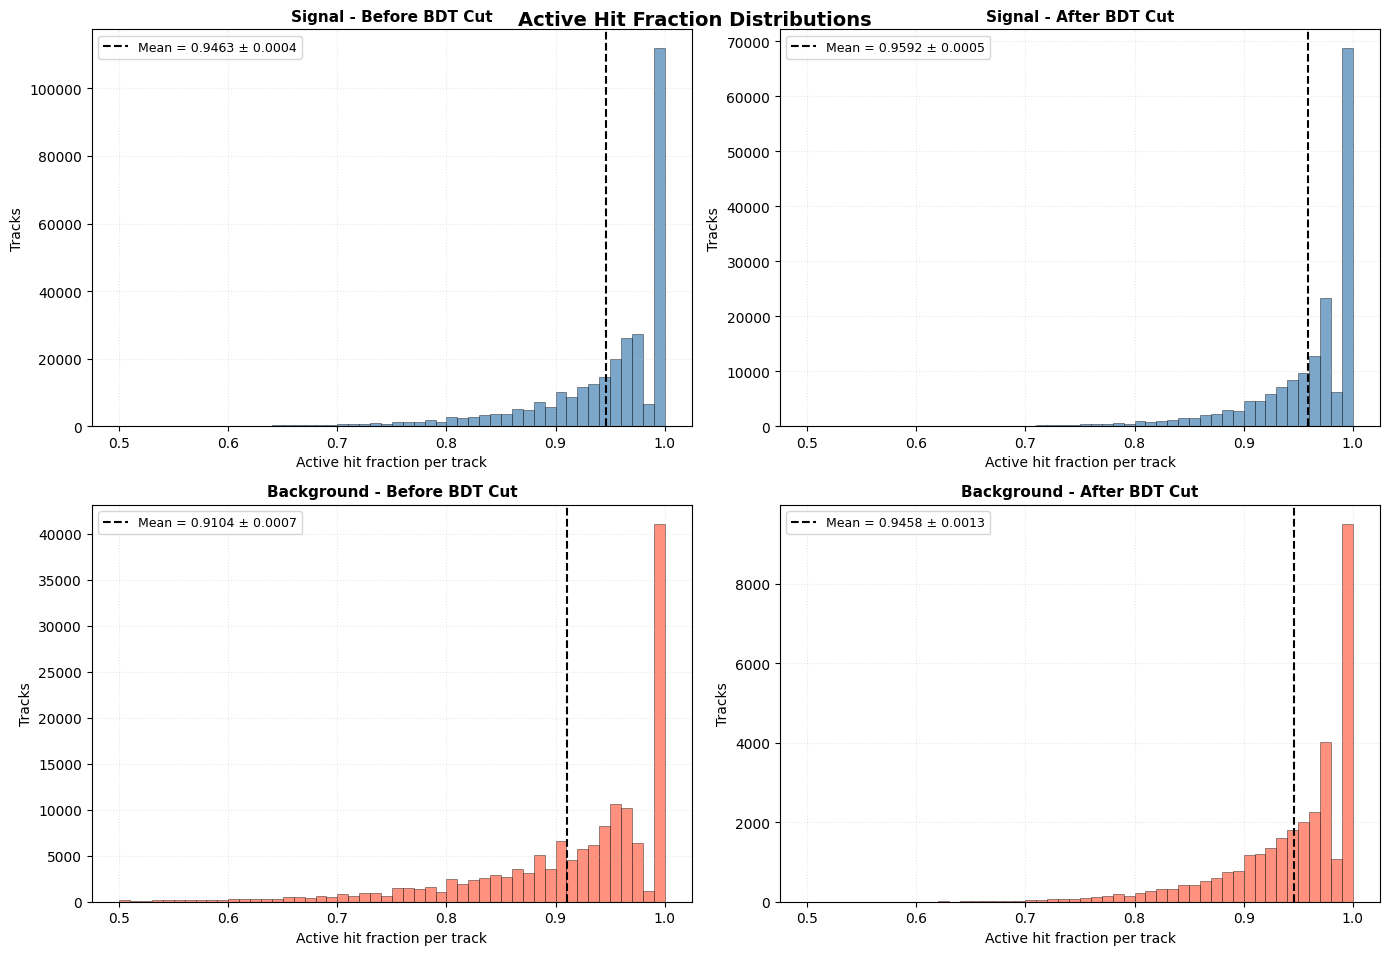

Plot saved and rendered successfully.


In [ ]:
# 1. Initialize the 2x2 grid canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
fig.suptitle("Active Hit Fraction Distributions", fontsize=14, fontweight='bold', y=0.95)

# 2. Map out the configurations using the newly activated independent arrays from the original file
configs = [
    (axes[0, 0], f_track_full[y_full == 1], "Signal - Before BDT Cut", "steelblue", f_sig_before, s_sig_before),
    (axes[0, 1], f_track_full[sig_pass],    "Signal - After BDT Cut",  "steelblue", f_sig_after,  s_sig_after),
    (axes[1, 0], f_track_full[y_full == 0], "Background - Before BDT Cut", "tomato", f_bkg_before, s_bkg_before),
    (axes[1, 1], f_track_full[bkg_pass],    "Background - After BDT Cut",  "tomato", f_bkg_after,  s_bkg_after),
]

# 3.Changed loop variable name from 'data' to 'array_data' to avoid conflicts
for ax, array_data, title, color, f_mean, f_sigma in configs:
    ax.hist(array_data, bins=50, range=(0.5, 1.0), color=color, alpha=0.7, edgecolor='black', linewidth=0.4)
    
    # Overlay the statistical mean line
    ax.axvline(f_mean, color='black', linestyle='--', linewidth=1.5,
               label=f"Mean = {f_mean:.4f} ± {f_sigma:.4f}")
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Active hit fraction per track", fontsize=10)
    ax.set_ylabel("Tracks", fontsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
# plt.savefig("active_hit_fraction_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved and rendered successfully.")

### Looking at how many trees from the 500 trees in the XGB model use factive to make a split at a node

In [ ]:
# Find trees where factive is used as a split
factive_trees = []
dump = booster.get_dump()  

for i, tree_text in enumerate(dump):
    if 'factive' in tree_text:
        factive_trees.append(i)
        
print(f"Trees using factive: {len(factive_trees)}")
print(f"First 20: {factive_trees[:20]}")

# Print the structure of the first few to find the clearest one
for tree_idx in factive_trees[:20]:
    print(f"\n-- Tree {tree_idx} --")
    print(dump[tree_idx])

Trees using factive: 147
First 20: [62, 66, 70, 71, 78, 80, 83, 84, 88, 90, 91, 93, 98, 100, 103, 105, 108, 112, 113, 114]

--- Tree 62 ---
0:[fambig<0.15625] yes=1,no=2,missing=2
	1:[factive<0.733333349] yes=3,no=4,missing=4
		3:leaf=-0.0368310437
		4:leaf=0.0274074115
	2:[momerr<0.378263265] yes=5,no=6,missing=6
		5:leaf=-0.00178102171
		6:leaf=-0.0319169573


--- Tree 66 ---
0:[fambig<0.280000001] yes=1,no=2,missing=2
	1:[factive<0.895833313] yes=3,no=4,missing=4
		3:leaf=-0.0096364934
		4:leaf=0.0184409972
	2:[momerr<0.505181491] yes=5,no=6,missing=6
		5:leaf=-0.0105878562
		6:leaf=-0.0362604521


--- Tree 70 ---
0:[momerr<0.0880625024] yes=1,no=2,missing=2
	1:[fitcon<7.04661019e-18] yes=3,no=4,missing=4
		3:leaf=-0.00624777889
		4:leaf=0.0335007831
	2:[factive<0.953846157] yes=5,no=6,missing=6
		5:leaf=-0.01478652
		6:leaf=0.00767862797


--- Tree 71 ---
0:[fambig<0.15625] yes=1,no=2,missing=2
	1:[nactive<26] yes=3,no=4,missing=4
		3:leaf=0.00344344904
		4:leaf=0.029004449
	2:[fac

### I choose tree ```# 78``` as it uses factive at both child nodes to make a split 

In [8]:
# 1.Build the DataFrame using the globally full data array (x_full)
x_valid_df = pd.DataFrame(x_full, columns=input_var_names)

# 2. Using y_full and booster ensures the rows sync up perfectly
dvalid_named = xgb.DMatrix(x_valid_df, label=y_full, feature_names=input_var_names)
all_leaf_ids = booster.predict(dvalid_named, pred_leaf=True)

# 3. Extract data profiles for the target tree (Tree 78)
tree_target_id = 78
leaf_ids_target = all_leaf_ids[:, tree_target_id]

factive_valid = x_valid_df['factive'].values
momerr_valid  = x_valid_df['momerr'].values

# 4. Loop through and compute statistics for each leaf terminal
print(f"\nTree {tree_target_id} - Active hit fraction (factive = nactive/nhits) ± σ at each leaf")
print(f"{'Leaf':>5s} {'N':>6s} {'f active':>10s} {'± σ':>8s}")
print(f"{'-'*40}")

for leaf in np.unique(leaf_ids_target):
    mask  = leaf_ids_target == leaf
    N     = mask.sum()
    if N == 0: continue  # Prevent division-by-zero errors
    
    f     = factive_valid[mask].mean()
    sigma = np.sqrt(f * (1 - f) / N)
    print(f"{int(leaf):>5d} {N:>6d} {f:>10.4f} {sigma:>8.4f}")


Tree 78 - Active hit fraction (factive = nactive/nhits) ± σ at each leaf
 Leaf      N   f active      ± σ
----------------------------------------
    3   2577     0.6715   0.0093
    4 173667     0.9531   0.0005
    5  62669     0.7871   0.0016
    6 213773     0.9658   0.0004


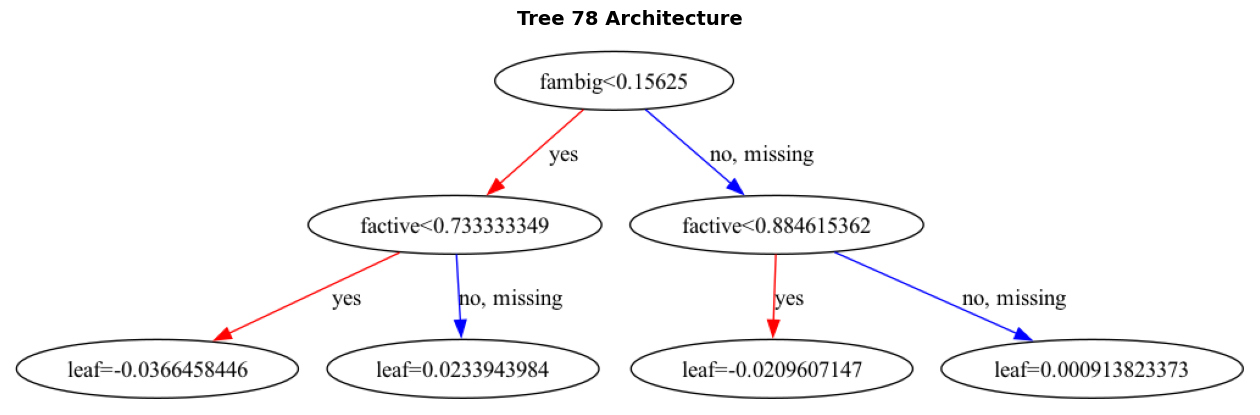

In [12]:
# 1. Force the booster to remember your exact names natively
booster.feature_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]

# 2. Draw the tree directly with zero external files or custom text overlays
plt.rcParams['figure.figsize'] = [16, 11]
xgb.plot_tree(booster, num_trees=78, rankdir='TB')

plt.title("Tree 78 Architecture", fontsize=14, fontweight='bold', pad=15)
plt.show()

In [13]:
# 1. Extract variables safely using the correct data matrix
x_valid_df = pd.DataFrame(x_full, columns=input_var_names)
momerr_valid = x_valid_df['momerr'].values

# 2.Use the target tree array that was extracted earlier
# leaf_ids_target contains the node columns for Tree 78
leaf_ids_78 = leaf_ids_target

print("Tree 78 - Momentum resolution at each leaf")
print(f"{'Leaf':>5s} {'N':>6s} {'mean momerr':>12s} {'± σ':>8s}")
print(f"{'-'*40}")

# 3. Process statistical distributions for each terminal leaf node
for leaf in np.unique(leaf_ids_78):
    mask = leaf_ids_78 == leaf
    N = mask.sum()
    if N == 0: continue # Protection against empty slices
    
    m = momerr_valid[mask].mean()
    
    # Calculate standard error of the mean (σ / sqrt(N))
    # Note: If a leaf has only 1 track, std() can return NaN; using ddof=0 or max protection avoids crashes
    std_val = momerr_valid[mask].std() if N > 1 else 0
    sigma = std_val / np.sqrt(N)
    
    print(f"{int(leaf):>5d} {N:>6d} {m:12.4f} {sigma:>8.4f}")

Tree 78 - Momentum resolution at each leaf
 Leaf      N  mean momerr      ± σ
----------------------------------------
    3   2577       0.1607   0.0247
    4 173667       0.0996   0.0001
    5  62669       0.2703   0.0040
    6 213773       0.1841   0.0004


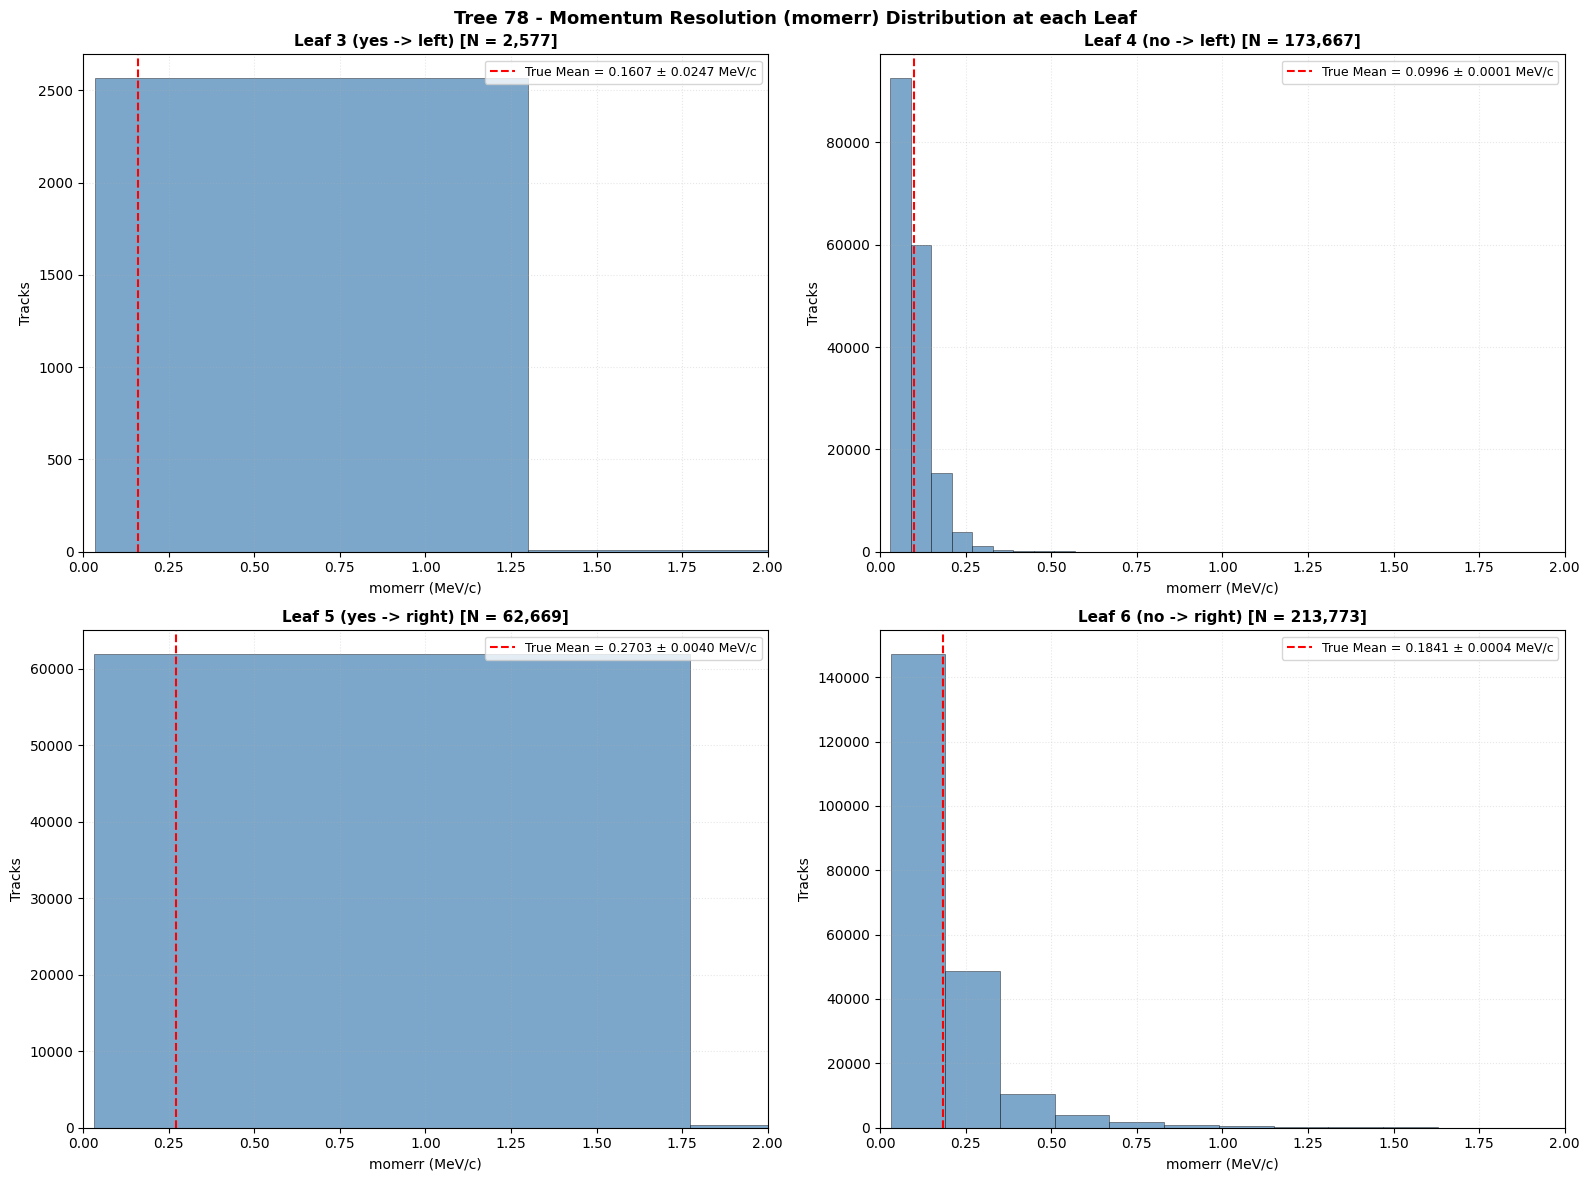

In [26]:
# 1. Initialize the 2x2 grid canvas safely
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Tree 78 - Momentum Resolution (momerr) Distribution at each Leaf", 
             fontsize=13, fontweight='bold', y=0.98)

# 2. Map out the layout coordinates for the 4 leaf panels
axes_mapping = {
    3: (axes[0, 0], 'Leaf 3 (yes -> left)'),
    4: (axes[0, 1], 'Leaf 4 (no -> left)'),
    5: (axes[1, 0], 'Leaf 5 (yes -> right)'),
    6: (axes[1, 1], 'Leaf 6 (no -> right)'),
}

# 3. DYNAMIC CALCULATION: Compute the true statistics automatically for each box
for leaf, (ax, title) in axes_mapping.items():
    mask = leaf_ids_target == leaf
    data = momerr_valid[mask]
    
    # Calculate the true numbers directly from the data arrays
    N = len(data)
    if N == 0: 
        ax.text(0.5, 0.5, "Empty Leaf", ha='center', va='center')
        continue
        
    mean = data.mean()
    std_val = data.std() if N > 1 else 0
    sigma = std_val / np.sqrt(N) # Standard error of the mean
    
    # Draw native histograms
    ax.hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.4)
    
    # Overlay the true statistical indicator lines
    ax.axvline(mean, color='red', linestyle='--', linewidth=1.5,
               label=f"True Mean = {mean:.4f} ± {sigma:.4f} MeV/c")
               
    ax.set_title(f"{title} [N = {N:,}]", fontsize=11, fontweight='bold', pad = 6)
    ax.set_xlabel("momerr (MeV/c)", fontsize=10)
    ax.set_ylabel("Tracks", fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3, linestyle=':')
    
    # Zoom in to keep layout focuses clean
    ax.set_xlim(0, 2.0)

plt.tight_layout()
plt.show()

## Now we move on ```Nactive``` analysis by perturbing ```Nactive``` cokumn by adding 1 in value

In [ ]:
# 1. Define file paths explicitly
DATA_DIR = "./"
ORIGINAL_FILE  = DATA_DIR + "trkqual_tree_v2.0_training.root"
PERTURBED_FILE = DATA_DIR + "trkqual_tree_v2.0_training_nactive_plus1.root"
tree_name      = "trkqualtree"

def get_features_from_file(file_path):
    """
    Opens a target ROOT file, computes physics engineering ratios dynamically, 
    and applies structural track quality masking identically to the loader pipeline.
    """
    with uproot.open(file_path) as file:
        tree = file[tree_name]
        arrays = tree.arrays(library="np")
        
        # Calculate magnitudes for tracking resolutions
        mom_ent = (arrays['trk_ent.mom.fCoordinates.fX']**2 + arrays['trk_ent.mom.fCoordinates.fY']**2 + arrays['trk_ent.mom.fCoordinates.fZ']**2)**0.5
        mom_mc  = (arrays['trk_ent_mc.mom.fCoordinates.fX']**2 + arrays['trk_ent_mc.mom.fCoordinates.fY']**2 + arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
        mom_res = mom_ent - mom_mc
        
        # Build training qualification boolean masks locally for this file
        h_mask = (mom_res > -0.25) & (mom_res < 0.25) #High quality tracks
        l_mask = mom_res > 0.7                        #Low quality tracks
        combined_quality_mask = h_mask | l_mask
        
        # Compute features correctly as ratios 
        nactive = arrays['trk.nactive'][combined_quality_mask]
        nhits   = arrays['trk.nhits'][combined_quality_mask]
        
        factive = nactive / nhits
        fambig  = arrays['trk.nnullambig'][combined_quality_mask] / nactive
        fstraws = arrays['trk.nmatactive'][combined_quality_mask] / nactive
        t0err   = arrays['trk_ent_pars.t0err'][combined_quality_mask]
        fitcon  = arrays['trk.fitcon'][combined_quality_mask]
        momerr  = arrays['trk_ent.momerr'][combined_quality_mask]
        
        # Stack variables into a clean 2D feature matrix
        x_filtered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
        return x_filtered

# 2. Get features for both files 
x_orig_filtered = get_features_from_file(ORIGINAL_FILE)
x_pert_filtered = get_features_from_file(PERTURBED_FILE)

y_pred_original_full  = best_model.predict_proba(x_orig_filtered)[:, 1]
y_pred_perturbed_full = best_model.predict_proba(x_pert_filtered)[:, 1]

# 4. Print Summary Diagnostics
print(f"Original matrix size:  {len(y_pred_original_full):,} tracks")
print(f"Perturbed matrix size: {len(y_pred_perturbed_full):,} tracks")
print(f"Original MVA Mean:     {y_pred_original_full.mean():.4f}") # MVA stands for Multivariate Analysis: This term simply refers to the raw, continuous classification quality-  
print(f"Perturbed MVA Mean:    {y_pred_perturbed_full.mean():.4f}") # score output by the XGBoost model (ranging from 0.0 for definitive background to 1.0 for definitive clean signal track)
print(f"Mean BDT Score Shift:  {(y_pred_perturbed_full - y_pred_original_full).mean():.6f}")

Original matrix size:  317,440 tracks
Perturbed matrix size: 317,440 tracks
Original MVA Mean:     0.7940
Perturbed MVA Mean:    0.8067
Mean BDT Score Shift:  0.012701


In [31]:
# We recreate the true label array calculating mom_res
delta = y_pred_perturbed_full - y_pred_original_full #This represents the total size of the filtered dataset, all the 317,440 tracks.
bdt_pass_orig = y_pred_original_full >= trkqual_cut
bdt_pass_pert = y_pred_perturbed_full >= trkqual_cut
changed = (bdt_pass_orig != bdt_pass_pert).sum() #This is the total number of tracks that crossed the BDT quality boundary line

# Re-extract the true physics signal/background labels for these filtered tracks
with uproot.open(ORIGINAL_FILE) as file:
    arrays = file[tree_name].arrays(library="np")
    mom_ent = (arrays['trk_ent.mom.fCoordinates.fX']**2 + arrays['trk_ent.mom.fCoordinates.fY']**2 + arrays['trk_ent.mom.fCoordinates.fZ']**2)**0.5
    mom_mc  = (arrays['trk_ent_mc.mom.fCoordinates.fX']**2 + arrays['trk_ent_mc.mom.fCoordinates.fY']**2 + arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
    mom_res_filtered = (mom_ent - mom_mc)[(mom_ent - mom_mc > -0.25) & (mom_ent - mom_mc < 0.25) | (mom_ent - mom_mc > 0.7)]
    
    y_full_filtered = np.zeros(len(mom_res_filtered))
    y_full_filtered[(mom_res_filtered > -0.25) & (mom_res_filtered < 0.25)] = 1

# Extract the change indices matching the filtered rows 
drift_mask = bdt_pass_orig != bdt_pass_pert
n_sig_changed = ((drift_mask) & (y_full_filtered == 1)).sum()
n_bkg_changed = ((drift_mask) & (y_full_filtered == 0)).sum()

print(f"Mean BDT shift:         {delta.mean():.6f} ± {delta.std():.6f}")
print(f"Tracks changing pass/fail: {changed:,} out of {len(delta):,}")
print(f"As a fraction:             {changed/len(delta)*100:.2f}%") # Fraction in precentage = [changed/len(delta)] * 100
print(f"\nOf the {changed:,} changed tracks:")
print(f" True Signal:     {n_sig_changed:,}")
print(f" True Background: {n_bkg_changed:,}")

Mean BDT shift:         0.012701 ± 0.024112
Tracks changing pass/fail: 8,964 out of 317,440
As a fraction:             2.82%

Of the 8,964 changed tracks:
 True Signal:     8,937
 True Background: 27


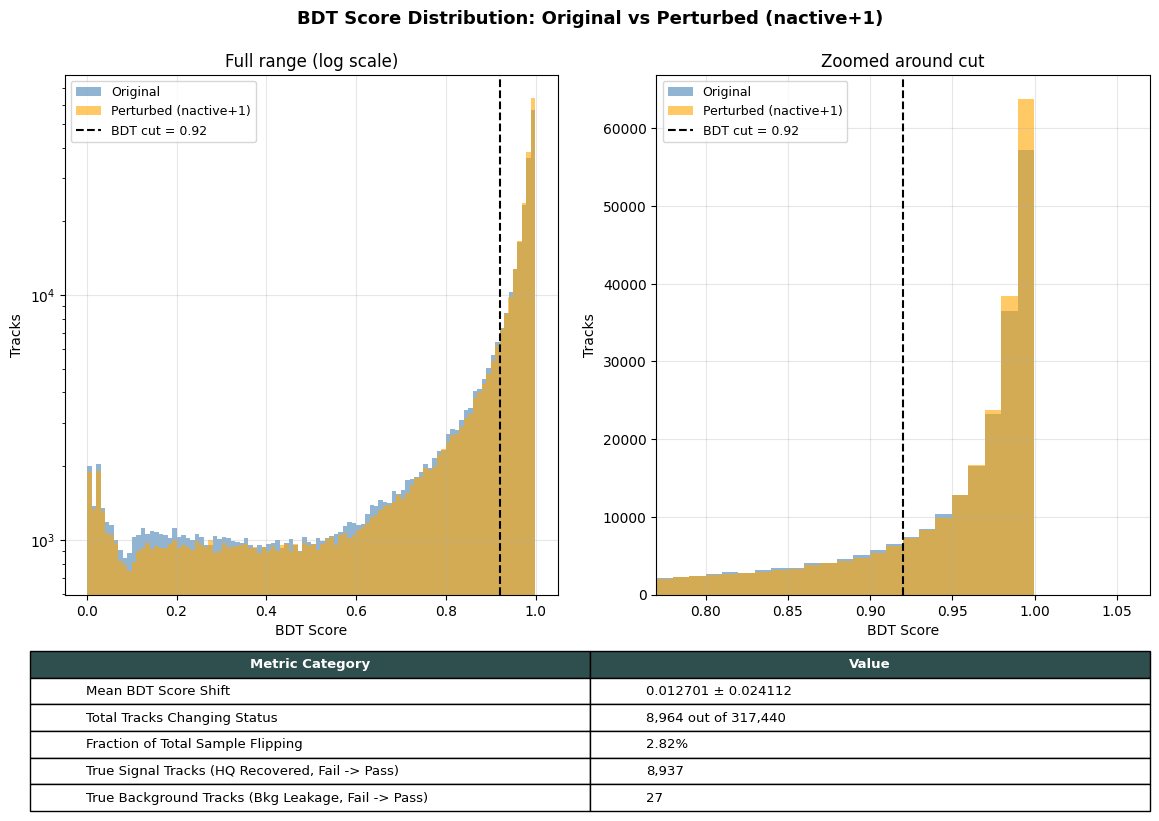

In [44]:
# 1. Gather the tracking metrics variables from the cell right above
num_sig = ((bdt_pass_orig != bdt_pass_pert) & (y_full_filtered == 1)).sum()
num_bkg = ((bdt_pass_orig != bdt_pass_pert) & (y_full_filtered == 0)).sum()

# 2. Build the structural figure grid
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle("BDT Score Distribution: Original vs Perturbed (nactive+1)", fontsize=13, fontweight='bold', y=0.98)

for ax, yscale, title in zip(axes, ['log', 'linear'], ['Full range (log scale)', 'Zoomed around cut']):
    ax.hist(y_pred_original_full, bins=100, alpha=0.6, color='steelblue', label='Original')
    ax.hist(y_pred_perturbed_full, bins=100, alpha=0.6, color='orange', label='Perturbed (nactive+1)')
    ax.axvline(trkqual_cut, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {trkqual_cut:.2f}')
    
    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks")
    ax.set_title(title)
    
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_yscale(yscale)
    
    if title.startswith('Zoomed'):
        ax.set_xlim(trkqual_cut - 0.15, trkqual_cut + 0.15)
        ax.set_yscale('linear')

# 3. Create the embedded data summary table below the subplots
table_data = [
    ["Mean BDT Score Shift", f"{delta.mean():.6f} ± {delta.std():.6f}"],
    ["Total Tracks Changing Status", f"{changed:,} out of {len(delta):,}"],
    ["Fraction of Total Sample Flipping", f"{changed/len(delta)*100:.2f}%"], 
    ["True Signal Tracks (HQ Recovered, Fail -> Pass)", f"{num_sig:,}"],
    ["True Background Tracks (Bkg Leakage, Fail -> Pass)", f"{num_bkg:,}"]
]

columns = ["Metric Category", "Value"]

# Position the table lower down to avoid colliding with the X-axis labels
table_ax = fig.add_axes([0.1, -0.22, 0.8, 0.18])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='left')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(9.5)
summary_table.scale(1.0, 1.6)

# Header styling
for (row, col), cell in summary_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#2f4f4f") 
        cell.set_text_props(ha='center')

plt.subplots_adjust(bottom=0.08)
plt.show()

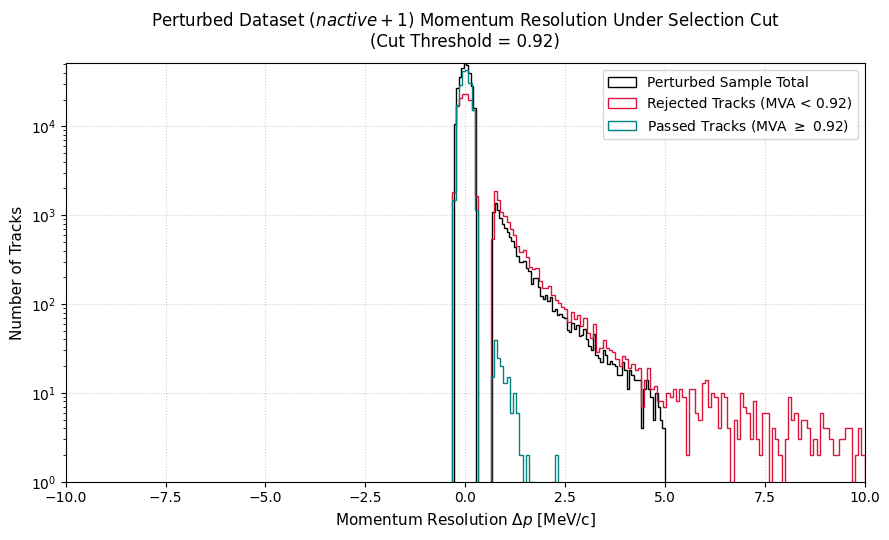

In [51]:
# Declare your standard physics resolution binning configuration locally
n_mom_res_bins = 250
min_mom_res = -10.0
max_mom_res = 5.0

# 1. Reuse the filtered momentum resolution we extracted 
# mom_res_filtered contains the 317,440 track resolutions for this specific study 
fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))

# 2. Plot the baseline total sample distribution for the perturbed stream
ax.hist(mom_res_filtered, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), 
        log=True, histtype='step', color='black', label="Perturbed Sample Total")

# 3. Filter using your PERTURBED predictions and baseline cut value
ax.hist(mom_res_filtered[y_pred_perturbed_full < trkqual_cut], bins=n_mom_res_bins, range=(-10.0, 10.0), #range=(min_mom_res, max_mom_res)
        log=True, histtype='step', color='crimson', label=f"Rejected Tracks (MVA < {trkqual_cut:.2f})")

ax.hist(mom_res_filtered[y_pred_perturbed_full >= trkqual_cut], bins=n_mom_res_bins, range=(-10.0, 10.0), #range=(min_mom_res, max_mom_res)
        log=True, histtype='step', color='teal', label=f"Passed Tracks (MVA $\geq$ {trkqual_cut:.2f})")


ax.legend(loc='upper right', fontsize=10)
ax.margins(0)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontsize=11)
ax.set_ylabel("Number of Tracks", fontsize=11)
ax.set_title(f"Perturbed Dataset ($nactive+1$) Momentum Resolution Under Selection Cut\n(Cut Threshold = {trkqual_cut:.2f})", 
             fontsize=12, pad=12)

plt.tight_layout()
plt.show()

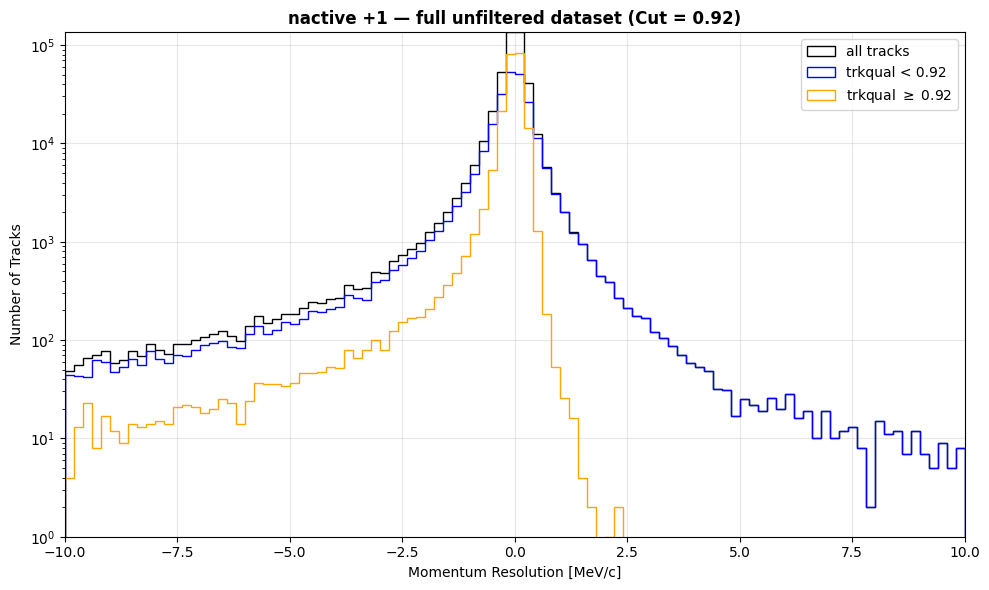

In [ ]:
opt_cut_nactive = trkqual_cut

with uproot.open(training_dataset_filename) as f:
    tree = f[training_dataset_treename]
    arrays = tree.arrays(library="np")
    
    # 1. Apply perturbation to the full raw array
    nactive = arrays['trk.nactive'] + 1
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    momerr  = arrays['trk_ent.momerr']

x_full_unfiltered = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
y_pred_full_unfiltered = best_model.predict_proba(x_full_unfiltered)[:, 1]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(mom_res, bins=100, range=(-10.0, 10.0), log=True, histtype='step', color='black', label='all tracks')
ax.hist(mom_res[y_pred_full_unfiltered < opt_cut_nactive], bins=100, range=(-10.0, 10.0), log=True, histtype='step', color='blue', label=f'trkqual < {opt_cut_nactive:.2f}')
ax.hist(mom_res[y_pred_full_unfiltered >= opt_cut_nactive], bins=100, range=(-10.0, 10.0), log=True, histtype='step', color='orange', label=f'trkqual $\geq$ {opt_cut_nactive:.2f}')
ax.legend()
ax.margins(0)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")
ax.set_title(f"nactive +1 — full unfiltered dataset (Cut = {opt_cut_nactive})", fontweight='bold')
plt.tight_layout()